<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc">
    <ul class="toc-item">
        <li>
            <span><a href="#1.-서포트벡터머신-(SVM)" data-toc-modified-id="1.-서포트벡터머신-(SVM)-1">
                <span class="toc-item-num">1&nbsp;&nbsp;</span>1. 서포트벡터머신 (SVM)
            </a></span>
        </li>
        <li>
            <span><a href="#2.-KNN" data-toc-modified-id="2.-KNN-2">
                <span class="toc-item-num">2&nbsp;&nbsp;</span>2. KNN
            </a></span>
        </li>
        <li>
            <span><a href="#3.-의사결정나무" data-toc-modified-id="3.-의사결정나무-3">
                <span class="toc-item-num">3&nbsp;&nbsp;</span>3. 의사결정나무
            </a></span>
        </li>
    </ul>
</div>
<hr>

## 1. 서포트벡터머신 (SVM)

In [1]:
import pandas as pd

c = pd.read_csv(
    "https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/classification.csv"
)

In [2]:
from sklearn.model_selection import train_test_split

X = c[["age", "interest"]]
y = c["success"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, train_size=0.7, random_state=1)
print(X_train.shape, X_test.shape)

(207, 2) (90, 2)


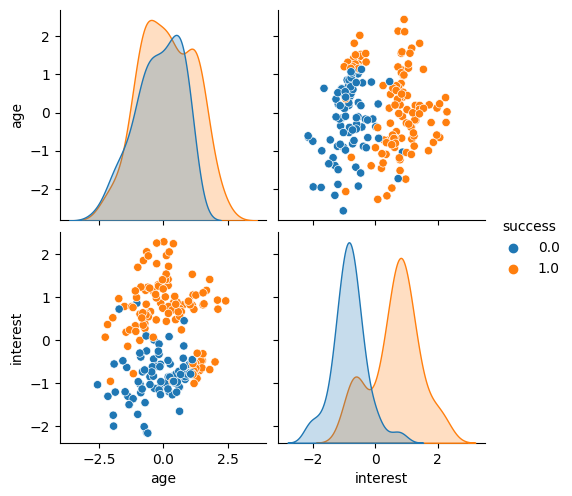

In [3]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_sc = scaler.fit_transform(X_train)

X_train_df = pd.DataFrame(X_train_sc, columns = X_train.columns)
X_train_df['success'] = y_train.reset_index(drop=True).copy()

sns.pairplot(hue="success", data=X_train_df)

In [4]:
from sklearn.svm import SVC

clf = SVC(C=0.5, random_state=45)
clf.fit(X_train_sc, y_train)

SVC(C=0.5, random_state=45)

In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

X_test_sc = scaler.transform(X_test)
pred = clf.predict(X_test_sc)

acc = accuracy_score(y_test, pred)
prc = precision_score(y_test, pred)
rcll = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print("정확도\t{}%".format(round(acc * 100, 2)))
print("정밀도\t{}%".format(round(prc * 100, 2)))
print("재현율\t{}%".format(round(rcll * 100, 2)))
print("F1\t{}%".format(round(f1 * 100, 2)))

정확도	95.56%
정밀도	96.08%
재현율	96.08%
F1	96.08%


In [6]:
import numpy as np

# 샘플 데이터 생성하기
X = np.sort(5 * np.random.rand(40, 1), axis=0)
y = np.sin(X).ravel()

# 타깃 데이터에 노이즈 추가하기
y[::5] += 3 * (0.5 - np.random.rand(8))

In [7]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X, y)

SVR()

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_error

pred = svr.predict(X)
mse = mean_squared_error(y, pred)
mae = mean_absolute_error(y, pred)
rmse = np.sqrt(mse)

print("MSE: ",mse)
print("MAE: ",mae)
print("RMSE: ",rmse)

MSE:  0.1566221106502645
MAE:  0.22433969455198963
RMSE:  0.39575511449666


## 2. KNN

In [9]:
import pandas as pd
import numpy as np

liver = pd.read_csv(
    "https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/indian_liver_patient.csv"
)

# 레이블 이진화: 간암환자(1) / 비환자(0)
liver["Dataset"] = np.where(liver["Dataset"] == 2, 0, 1)
# 성별 원핫인코딩
liver["Gender"] = np.where(liver["Gender"] == "Female", 0, 1)
# 결측치 제거
liver.dropna(axis=0, inplace=True)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X = liver[liver.columns.difference(["Dataset"])]
y = liver["Dataset"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, train_size=0.7, random_state=1)

clf = KNeighborsClassifier(n_neighbors=15)
clf.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=15)

In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

pred = clf.predict(X_test)

acc = accuracy_score(y_test, pred)
prc = precision_score(y_test, pred)
rcll = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print("정확도\t{}%".format(round(acc * 100, 2)))
print("정밀도\t{}%".format(round(prc * 100, 2)))
print("재현율\t{}%".format(round(rcll * 100, 2)))
print("F1\t{}%".format(round(f1 * 100, 2)))

정확도	63.79%
정밀도	72.93%
재현율	78.23%
F1	75.49%


## 3. 의사결정나무

In [12]:
import pandas as pd

credit = pd.read_csv(
    "https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/credit_final.csv"
)

In [13]:
from sklearn.model_selection import train_test_split

feature_columns = list(credit.columns.difference(["credit.rating"]))
X = credit[feature_columns]
y = credit["credit.rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=1)

print(X_train.shape, X_test.shape)

(700, 20) (300, 20)


In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

clf = DecisionTreeClassifier(max_depth=5)
clf.fit(X_train, y_train)

pred = clf.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.52      0.31      0.39        90
           1       0.75      0.88      0.81       210

    accuracy                           0.71       300
   macro avg       0.63      0.59      0.60       300
weighted avg       0.68      0.71      0.68       300



In [15]:
importances = clf.feature_importances_
column_nm = pd.DataFrame(X.columns)
feature_importances = pd.concat(
    [column_nm, pd.DataFrame(importances)], axis=1)
feature_importances.columns = ["feature_nm", "importances"]

# 중요도 기준으로 내림차순 정렬
print(feature_importances.sort_values("importances", ascending=False))

                        feature_nm  importances
0                  account.balance     0.263282
5           credit.duration.months     0.187908
16  previous.credit.payment.status     0.123825
4                    credit.amount     0.098532
1                              age     0.097293
6                   credit.purpose     0.059083
18                         savings     0.053080
2                   apartment.type     0.036866
15                   other.credits     0.034003
13                  marital.status     0.025168
17              residence.duration     0.020960
14                      occupation     0.000000
10                  foreign.worker     0.000000
12                installment.rate     0.000000
11                       guarantor     0.000000
9              employment.duration     0.000000
8                       dependents     0.000000
7                   current.assets     0.000000
3                     bank.credits     0.000000
19                       telephone     0

In [16]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 임의 데이터 생성 및 노이즈 추가
np.random.seed(0)
X = np.sort(5 * np.random.rand(400, 1), axis=0)
y = np.sin(X).ravel()
y[::1] += 1 * (0.5 - np.random.rand(400))

# 학습·평가 분할
train_x, test_x, train_y, test_y = train_test_split(
    X, y, train_size=0.7, random_state=1)

In [17]:
# max_depth 2와 5 비교
regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor(max_depth=5)

y_1 = regr_1.fit(train_x, train_y).predict(test_x)
y_2 = regr_2.fit(train_x, train_y).predict(test_x)

In [18]:
# 성능 비교
for pred, label in [(y_1, "depth=2"), (y_2, "depth=5")]:
    mse  = mean_squared_error(test_y, pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(test_y, pred)
    print(f"{label} | MSE: {mse:.3f}, RMSE: {rmse:.3f}, MAE: {mae:.3f}")

depth=2 | MSE: 0.123, RMSE: 0.350, MAE: 0.292
depth=5 | MSE: 0.123, RMSE: 0.351, MAE: 0.302
